In [1]:
# read text into python, make everything lowercase, remove punctuation (~10s)
def getText():
    valid = 'abcdefghijklmnopqrstuvwxyz '
    with open("AllCombined.txt") as f:
        raw = f.read()
    low = raw.lower().replace("\n", " ")
    letters_only = ''.join(char for char in low if char in valid)
    return letters_only

txt = getText()
print(txt[:500])

 april  april apr is the fourth month of the year in the julian and gregorian calendars and comes between march and may it is one of four months to have  days  april always begins on the same day of the week as july and additionally january in leap years april always ends on the same day of the week as december  april comes between march and may making it the fourth month of the year it also comes first in the year out of the four months that have  days as june september and november are later i


In [2]:
import cupy as np

In [3]:
# tokenize and build vocab
from collections import Counter
vocab_sz = 10000
stop_words = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself", "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself", "it", "its", "itself", "they", "them", "their", "theirs", "themselves", "what", "which", "who", "whom", "this", "that", "these", "those", "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because", "as", "until", "while", "of", "at", "by", "for", "with", "about", "against", "between", "into", "through", "during", "before", "after", "above", "below", "to", "from", "up", "down", "in", "out", "on", "off", "over", "under", "again", "further", "then", "once", "here", "there", "when", "where", "why", "how", "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "no", "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s", "t", "can", "will", "just", "don", "should", "now"]

lst = [word for word in txt.split() if word != '']
filtered = [word for word in lst if word not in stop_words]
vocab = [word for word, cnt in Counter(filtered).most_common(vocab_sz) if word not in stop_words]
vocab_sz = len(vocab)

vocab_st = set(vocab)
dict = {word: i for i, word in enumerate(vocab)}
data = [dict[word] for word in filtered if word in vocab_st]
print(data[:20])
print(len(data))
print(len(vocab))
print(len(stop_words))



[63, 63, 588, 876, 50, 3173, 6052, 417, 41, 16, 3, 116, 590, 294, 63, 609, 1843, 134, 1016, 52]
13316348
10000
127


In [4]:
# training data, loop over the text to generate target and context
# import numpy as np
import Neural as Neur
np.random.seed(400)
x = []
y = []
window = 10
for i in range(window, len(data) - window):
    start = i - window
    end = i + window + 1
    context = []
    for j in range(start, end):
        if i != j:
            context.append(data[j])
    x.append(context)
    y.append(data[i])


x = np.array(x)
y = np.array(y)
indices = np.arange(len(x))
np.random.shuffle(indices)
x_shuffled = x[indices]
y_shuffled = y[indices]
end = int(len(x_shuffled) * 0.9)

X_train = x_shuffled[:end]
Y_train = y_shuffled[:end]
X_test = x_shuffled[end:]
Y_test = y_shuffled[end:]
print(len(Y_train))



11984695


In [5]:
# neural network!
import importlib
from tqdm import tqdm
import cupyx
importlib.reload(Neur)

sz = len(Y_train)

def get_cbow(context):
    ctx = np.asarray(context)
    mat = np.zeros((len(ctx), vocab_sz), dtype=np.float32)
    rows = np.repeat(np.arange(len(ctx)), ctx.shape[1])
    cupyx.scatter_add(mat, (rows, ctx.ravel()), np.float32(1.0 / (2 * window)))
    return mat

def get_one_hot(indices):
    mat = np.zeros((len(indices), vocab_sz), dtype=np.float32)
    mat[np.arange(len(indices)), indices] = 1
    return mat



In [6]:
import time
import copy

def step_sgd(N_a, state, g):
    params = N_a.get_params()
    N_a.set_params(params - state['lr'] * g)
    
    state['track'].append(state['lr'])
    return state

def get_mat(N_a, d):
    d1 = N_a.list_layers[0].list_layers[0]
    dim, V = d1.n_sortie, d1.n_entree
    vdot = d[:dim * V].reshape(dim, V)
    b1 = d[dim * V: dim * V + dim]
    udot = d[dim * V + dim: dim * V * 2 + dim].reshape(V, dim)
    b2 = d[dim * V * 2 + dim:]
    return vdot, b1, udot, b2

def curvature(N_a, d):
    N = N_a.list_layers[0]
    l1, l2, loss = N.list_layers[0], N.list_layers[1], N_a.list_layers[1]
    h = l2.save_X
    z = loss.save_X
    xin = l1.save_X
    tar = loss.save_D
    u = l2.A
    vdot, b1, udot, b2 = get_mat(N_a, d)
    
    hdot = vdot @ xin + b1[:, None]
    zdot = udot @ h + u @ hdot + b2[:, None]
    zmax = np.max(z, axis=0)
    p = np.exp(z - zmax)
    p /= np.sum(p, axis=0)
    mu = np.sum(p * zdot, axis=0)
    S = np.sum(p * zdot**2, axis=0)
    gdot = udot.T @ (p - tar)
    kappa = (S - mu**2) + 2.0 * np.sum(gdot * hdot, axis=0)
    return kappa

def step_red(N_a, state, g, lv, X):
    beta3, ell, eps = 0.9, 1.0, 1e-4
    
    p = N_a.get_params()
    d = g
    nrm2 = np.dot(d, d)

    kappa = curvature(N_a, d)
    ck = max(float(np.mean(np.abs(kappa))) / nrm2, 1e-20)
    
    state['chat'] = beta3 * state['chat'] + (1 - beta3) * ck
    ctilde = state['chat'] / (1 - beta3 ** (state['k'] + 1))
    Lk = max(ctilde, ck)
    rk = np.dot(d, g) / (2 * nrm2 * Lk)

    l1, l2 = N_a.list_layers[0].list_layers[0], N_a.list_layers[0].list_layers[1]
    B = float(max(np.linalg.norm(l1.A, axis=0).max(), np.linalg.norm(l2.A, axis=1).max()))
    state['track'].append((float(np.mean(kappa) / nrm2), B, float(rk)))
    
    N_a.set_params(p - ell * rk * d)
    state['k'] += 1
    return state

def step_adam(N_a, state, g):
    b1, b2, e = 0.9, 0.999, 1e-8

    state['m'] = b1 * state['m'] + (1 - b1) * g
    state['v'] = b2 * state['v'] + (1 - b2) * g**2
    mh = state['m'] / (1 - b1 ** (state['k'] + 1))
    vh = state['v'] / (1 - b2 ** (state['k'] + 1))

    p = N_a.get_params()
    p -= state['lr'] * mh / (np.sqrt(vh) + e)
    N_a.set_params(p)
    state['k'] += 1
    return state

def step_adahessian(N_a, state, g, loss_layer, X, Y):
    b1, b2, e, eps = 0.9, 0.999, 1e-4, 1e-3
    p = N_a.get_params()
    z = np.random.choice([-1.0, 1.0], size=len(p)).astype(np.float32)
    N_a.set_params(p + eps * z)
    loss_layer.save_D = Y.T
    N_a.forward(X.T)
    gp, _ = N_a.backward(None)

    N_a.set_params(p)
    D = z * (gp - g) / eps
    D = np.clip(D, -2.0, 2.0)

    state['m'] = b1 * state['m'] + (1 - b1) * g
    state['v'] = b2 * state['v'] + (1 - b2) * (D**2)
    mh = state['m'] / (1 - b1 ** (state['k'] + 1))
    vh = state['v'] / (1 - b2 ** (state['k'] + 1))

    p -= state['lr'] * mh / (np.sqrt(vh) + e)
    N_a.set_params(p)
    state['k'] += 1
    return state

def step_redm(N_a, state, g, lv, X):
    beta3, b1, ell, eps = 0.9, 0.9, 1.0, 1e-4
    
    p = N_a.get_params()
    state['m'] = b1 * state['m'] + (1 - b1) * g
    mh = state['m'] / (1 - b1 ** (state['k'] + 1))
    d = mh
    nrm2 = np.dot(d, d)
    kappa = curvature(N_a, d)
    ck = max(float(np.mean(np.abs(kappa))) / nrm2, 1e-20)
    
    state['chat'] = beta3 * state['chat'] + (1 - beta3) * ck
    ctilde = state['chat'] / (1 - beta3 ** (state['k'] + 1))
    Lk = max(ctilde, ck)
    rk = np.dot(d, g) / (2 * nrm2 * Lk)

    l1, l2 = N_a.list_layers[0].list_layers[0], N_a.list_layers[0].list_layers[1]
    B = float(max(np.linalg.norm(l1.A, axis=0).max(), np.linalg.norm(l2.A, axis=1).max()))
    state['track'].append((float(np.mean(kappa) / nrm2), B, float(rk)))
    
    N_a.set_params(p - ell * rk * d)
    state['k'] += 1
    return state

def step_redhessian(N_a, state, g, loss_layer, X, Y):
    b1, b2, beta3, ell, e, eps = 0.9, 0.999, 0.9, 1.0, 1e-4, 1e-3
    p = N_a.get_params()
    z = np.random.choice([-1.0, 1.0], size=len(p)).astype(np.float32)
    N_a.set_params(p + eps * z)
    loss_layer.save_D = Y.T
    N_a.forward(X.T)
    gp, _ = N_a.backward(None)

    N_a.set_params(p)
    N_a.forward(X.T)
    D = z * (gp - g) / eps
    D = np.clip(D, -2.0, 2.0)

    state['m'] = b1 * state['m'] + (1 - b1) * g
    state['v'] = b2 * state['v'] + (1 - b2) * (D**2)
    mh = state['m'] / (1 - b1 ** (state['k'] + 1))
    vh = state['v'] / (1 - b2 ** (state['k'] + 1))
    d = mh / (np.sqrt(vh) + e)

    nrm2 = np.dot(d, d)
    kappa = curvature(N_a, d)
    ck = max(float(np.mean(np.abs(kappa))) / nrm2, 1e-20)
    
    state['chat'] = beta3 * state['chat'] + (1 - beta3) * ck
    ctilde = state['chat'] / (1 - beta3 ** (state['k'] + 1))
    Lk = max(ctilde, ck)
    rk = np.dot(d, g) / (2 * nrm2 * Lk)

    step = ell * rk * d
    snorm = float(np.sqrt(np.dot(step, step)))
    if snorm > 5.0:
        step = step * (5.0 / snorm)

    l1, l2 = N_a.list_layers[0].list_layers[0], N_a.list_layers[0].list_layers[1]
    B = float(max(np.linalg.norm(l1.A, axis=0).max(), np.linalg.norm(l2.A, axis=1).max()))
    state['track'].append((float(np.mean(kappa) / nrm2), B, float(rk)))
    
    N_a.set_params(p - step)
    state['k'] += 1
    return state


def build_net(optimizer, dim, epochs, batch, lr=1.0, decay=1.0):
    np.random.seed(3000)
    history = []
    history_00 = []
    Nh = []

    N = Neur.Network([Neur.Dense(vocab_sz, dim), Neur.Dense(dim, vocab_sz)])
    loss_layer = Neur.Ilogit_and_KL(None)
    N_a = Neur.Network([N, loss_layer])

    state = {'k': 0, 'lr': lr, 'decay': decay, 'track':[]}
    if optimizer in ['adahessian', 'adam', 'redm', 'redhessian']:
        state['m'] = np.zeros(N_a.nb_params, dtype=np.float32)
    if optimizer in ['adahessian', 'adam', 'redhessian']:
        state['v'] = np.zeros(N_a.nb_params, dtype=np.float32)
    if optimizer in ['red', 'redm', 'redhessian']:
        state['chat'] = 0.0

    start_time = time.time()
    times = []

    for epoch in range(epochs):
        total_loss = 0
        indices = np.arange(sz)
        np.random.shuffle(indices)
        X_shuffled = X_train[indices]
        Y_shuffled = Y_train[indices]
        batch_loop = tqdm(range(0, len(X_shuffled), batch),
                          desc=f"Epoch {epoch + 1}/{epochs}",
                          unit="batch")

        batches = 0

        for i in batch_loop:

            X_cur = get_cbow(X_shuffled[i:i+batch])
            Y_cur = get_one_hot(Y_shuffled[i:i+batch])

            loss_layer.save_D = Y_cur.T
            loss = N_a.forward(X_cur.T)
            total_loss += loss
            grads, in_grad = N_a.backward(None)

            gnorm = np.sqrt(np.dot(grads, grads))
            if gnorm > 5.0:
                grads = grads * (5.0 / gnorm)
            
            # history_00.append(grads[0])

            if optimizer == 'sgd':
                state = step_sgd(N_a, state, grads)
            if optimizer == 'red':
                state = step_red(N_a, state, grads, loss, X_cur)
            if optimizer == 'redm':
                state = step_redm(N_a, state, grads, loss, X_cur)
            if optimizer == 'adam':
                state = step_adam(N_a, state, grads)
            if optimizer == 'adahessian':
                state = step_adahessian(N_a, state, grads, loss_layer, X_cur, Y_cur)
            if optimizer == 'redhessian':
                state = step_redhessian(N_a, state, grads, loss_layer, X_cur, Y_cur)

            batches += 1

            if i % 5 == 0:
                batch_loop.set_postfix({"loss": f"{total_loss / batches:.2f}"})

        avg_loss = float(total_loss / batches)
        history.append(avg_loss)

        state['lr'] *= state['decay']
        times.append(time.time() - start_time)
        for layer in N.list_layers:
            layer.save_X = None
        Nh.append(copy.deepcopy(N))

    return Nh, history, state['track'], times



In [7]:
import matplotlib.pyplot as plt
import itertools

networks = {}
loss_history = {}
grad_history = {}
runtime = {}

optimizers = ['adam', 'redhessian', 'redm', 'red', 'adahessian', 'sgd']
lr = {'sgd': 3.0, 'adahessian': 0.1, 'adam': 0.01}
for optim in optimizers:
    print(optim)
    if optim == 'sgd':
        networks[optim], loss_history[optim], grad_history[optim], runtime[optim] = build_net(optim, 300, 20, 8096, 4.0, 0.95)
    elif optim == 'red' or optim == 'redm' or optim == 'redhessian':
        networks[optim], loss_history[optim], grad_history[optim], runtime[optim] = build_net(optim, 300, 20, 8096)
    else:
        networks[optim], loss_history[optim], grad_history[optim], runtime[optim] = build_net(optim, 300, 20, 8096, lr[optim])

adam


Epoch 20/20: 100%|██████████| 1481/1481 [00:47<00:00, 31.36batch/s, loss=5.91]


redhessian


Epoch 20/20: 100%|██████████| 1481/1481 [02:22<00:00, 10.39batch/s, loss=5.90]


redm


...

Epoch 20/20: 100%|██████████| 1481/1481 [01:12<00:00, 20.47batch/s, loss=7.17]


adahessian


Epoch 20/20: 100%|██████████| 1481/1481 [02:35<00:00,  9.52batch/s, loss=5.86]


sgd


Epoch 20/20: 100%|██████████| 1481/1481 [01:32<00:00, 16.06batch/s, loss=7.21]


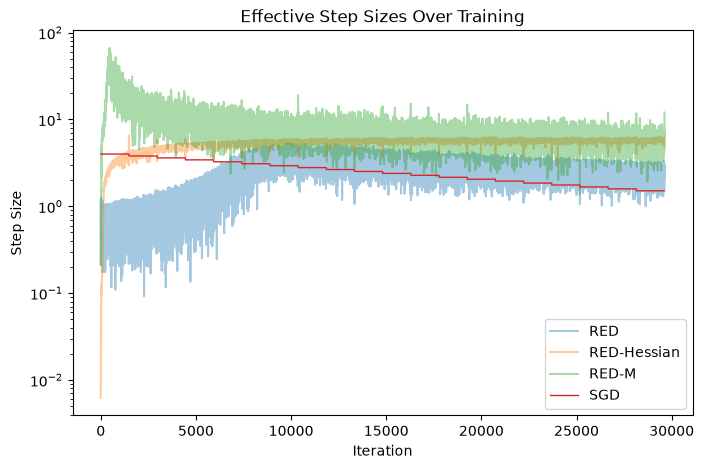

In [96]:
rk_red  = onp.array([t[2] for t in grad_history['red']])
rk_redh = onp.array([t[2] for t in grad_history['redhessian']])
rk_redm = onp.array([t[2] for t in grad_history['redm']])

plt.figure(figsize=(8,5))
plt.plot(rk_red, alpha=0.4, label=r'RED')
plt.plot(rk_redh, alpha=0.4, label=r'RED-Hessian')
plt.plot(rk_redm, alpha=0.4, label=r'RED-M')
plt.plot(grad_history['sgd'], lw=1, label='SGD')
plt.yscale('log')
plt.title("Effective Step Sizes Over Training")
plt.xlabel('Iteration')
plt.ylabel('Step Size')
plt.legend()
plt.savefig('step-sizes.png')
plt.show()

In [8]:
batch = 8096

for optim2 in optimizers:
    N = networks[optim2][-1]
    loss_layer = Neur.Ilogit_and_KL(None)
    N_a = Neur.Network([N, loss_layer])

    total_loss = 0
    batches = 0

    for k in range(0, len(X_test), batch):
        X_cur = get_cbow(X_test[k:k+batch])
        Y_cur = get_one_hot(Y_test[k:k+batch])

        loss_layer.save_D = Y_cur.T
        loss = N_a.forward(X_cur.T)

        total_loss += loss
        batches += 1

    avg = total_loss / batches
    print(f"{optim2} Test Loss: {avg:.4f}")

adam Test Loss: 6.3083
redhessian Test Loss: 6.3109
redm Test Loss: 6.6261
red Test Loss: 7.1650
adahessian Test Loss: 6.2863
sgd Test Loss: 7.2079


1


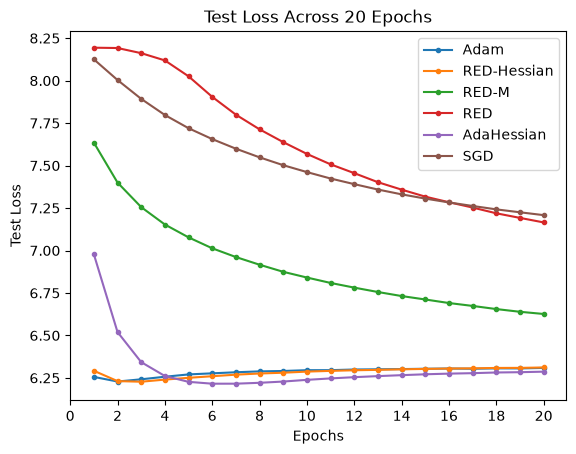

In [9]:
display = {"sgd": "SGD", "red": "RED", "redm": "RED-M", "adahessian": "AdaHessian", "adam": "Adam", "redhessian": "RED-Hessian"}
def evaluate_and_plot_test_loss():
    test_losses = {optim: [] for optim in optimizers}
    batch_size = 4096
    print(1)
    for optim in optimizers:
        for N in networks[optim]:
            loss_layer = Neur.Ilogit_and_KL(None)
            N_a = Neur.Network([N, loss_layer])
            total_loss = 0
            batches = 0
            for k in range(0, len(X_test), batch_size):
                X_cur = get_cbow(X_test[k : k + batch_size])
                Y_cur = get_one_hot(Y_test[k : k + batch_size])

                loss_layer.save_D = Y_cur.T
                loss = N_a.forward(X_cur.T)

                total_loss += loss
                batches += 1

            test_losses[optim].append(float(total_loss) / batches)

    for optim, losses in test_losses.items():
        plt.plot(range(1, 21), losses, label=display[optim], marker="o", markersize=3)

    plt.xlabel("Epochs")
    plt.ylabel("Test Loss")
    plt.title("Test Loss Across 20 Epochs")
    plt.legend()
    plt.xticks(range(0, 21, 2))
    plt.show()
    return test_losses

test_losses = evaluate_and_plot_test_loss()

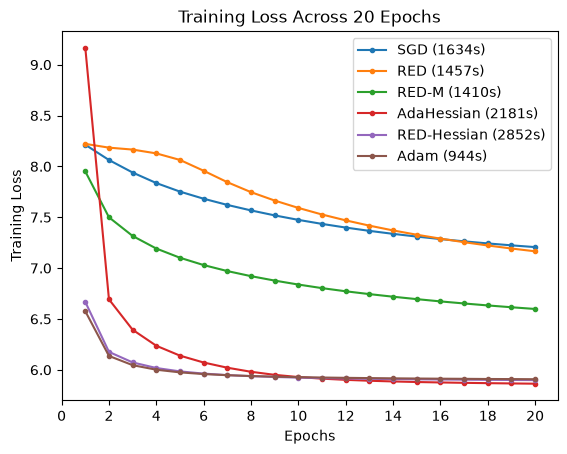

In [10]:
#plt.figure(figsize=(10,6))

plt.plot(range(1, 21), loss_history['sgd'], marker='o',markersize=3, label=f'SGD ({round(runtime['sgd'][-1])}s)')
plt.plot(range(1, 21), loss_history['red'], marker='o',markersize=3, label=f'RED ({round(runtime['red'][-1])}s)')
plt.plot(range(1, 21), loss_history['redm'], marker='o',markersize=3, label=f'RED-M ({round(runtime['redm'][-1])}s)')
plt.plot(range(1, 21), loss_history['adahessian'], marker='o', markersize=3, label=f'AdaHessian ({round(runtime['adahessian'][-1])}s)')
plt.plot(range(1, 21), loss_history['redhessian'], marker='o', markersize=3, label=f'RED-Hessian ({round(runtime['redhessian'][-1])}s)')
plt.plot(range(1, 21), loss_history['adam'], marker='o', markersize=3, label=f'Adam ({round(runtime['adam'][-1])}s)')

plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title("Training Loss Across 20 Epochs")
plt.xticks(np.arange(0, 21, 2).get())
plt.legend()
plt.show()



In [12]:
embed = networks['adahessian'][-1].list_layers[0].A.T
norms = np.linalg.norm(embed, axis=1, keepdims=True)
norm_embed = embed / norms

def get_similar(word, top_k=5):
    if word not in dict:
        print(f"'{word}' not found.")
        return

    word_idx = dict[word]
    word_vec = norm_embed[word_idx]

    similar = norm_embed @ word_vec
    nearest = np.argsort(similar)[::-1]

    print(f"Words most similar to '{word}':")
    for i in range(1, top_k + 1):
        idx = int(nearest[i])
        score = similar[idx]
        print(f"  - {vocab[idx]}: {score:.4f}")

get_similar("king")
get_similar("apple")
get_similar("war")
get_similar("queen")
get_similar("battle")



Words most similar to 'king':
  - donkey: 0.3036
  - kings: 0.3022
  - hong: 0.2934
  - emperor: 0.2917
  - throne: 0.2801
Words most similar to 'apple':
  - ipod: 0.3007
  - iphone: 0.2448
  - intel: 0.2218
  - ipad: 0.2215
  - windows: 0.2188
Words most similar to 'war':
  - wars: 0.3292
  - battle: 0.2777
  - occupation: 0.2733
  - cup: 0.2542
  - heritage: 0.2499
Words most similar to 'queen':
  - princess: 0.3565
  - xvi: 0.2813
  - monarch: 0.2626
  - king: 0.2518
  - royal: 0.2427
Words most similar to 'battle':
  - battles: 0.4895
  - casualties: 0.2830
  - war: 0.2777
  - attacks: 0.2749
  - siege: 0.2702


In [16]:
def find_analogy(a, b, c, top_k=1):
    if any(w not in dict for w in [a, b, c]):
        print("One of the words is missing from the vocab.")
        return

    vec_a = norm_embed[dict[a]]
    vec_b = norm_embed[dict[b]]
    vec_c = norm_embed[dict[c]]

    target = vec_b - vec_a + vec_c
    target = target / np.linalg.norm(target)
    similar = norm_embed @ target
    nearest = np.argsort(similar)[::-1]

    print(f"'{a}' is to '{b}' as '{c}' is to:")

    count = 0
    for indx in nearest:
        idx = int(indx)
        word = vocab[idx]

        if word not in [a, b, c]:
            score = similar[idx]
            print(f"  {count + 1}. {word} ({score:.4f})")
            count += 1

        if count == top_k:
            break

find_analogy("man", "king", "woman", top_k=3) # queen
find_analogy("son", "father", "daughter", top_k=3) # mother
find_analogy("boy", "brother", "girl", top_k=3) # sister
find_analogy("paris", "france", "berlin", top_k=3) # germany
find_analogy("france", "paris", "japan", top_k=3) # tokyo
find_analogy("bright", "dark", "white", top_k=3) # black
find_analogy("small", "smaller", "big", top_k=3) # bigger
find_analogy("writing", "wrote", "making", top_k=3) # made
find_analogy("america", "american", "canada", top_k=3) # canadian


'man' is to 'king' as 'woman' is to:
  1. throne (0.7674)
  2. vi (0.7416)
  3. queen (0.7405)
'son' is to 'father' as 'daughter' is to:
  1. mother (0.9443)
  2. sister (0.9026)
  3. parents (0.8991)
'boy' is to 'brother' as 'girl' is to:
  1. sister (0.8481)
  2. younger (0.8259)
  3. uncle (0.8243)
'paris' is to 'france' as 'berlin' is to:
  1. germany (0.5678)
  2. german (0.5385)
  3. rhinewestphalia (0.5341)
'france' is to 'paris' as 'japan' is to:
  1. tokyo (0.6903)
  2. selected (0.6199)
  3. osaka (0.6133)
'bright' is to 'dark' as 'white' is to:
  1. black (0.8770)
  2. brown (0.7473)
  3. gray (0.7061)
'small' is to 'smaller' as 'big' is to:
  1. bigger (0.5821)
  2. making (0.5651)
  3. bars (0.5443)
'writing' is to 'wrote' as 'making' is to:
  1. make (0.7166)
  2. sell (0.7151)
  3. buy (0.6264)
'america' is to 'american' as 'canada' is to:
  1. canadian (0.6719)
  2. clark (0.5703)
  3. warren (0.5667)


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

def cosine_heatmap(words, embed, title):
    embed = embed.get()
    idx = [dict[w] for w in words]
    
    cur_embed = embed[idx]
    norms = onp.linalg.norm(cur_embed, axis=1, keepdims=True)
    norm_embed = cur_embed / norms
    sim = norm_embed @ norm_embed.T
    mask = onp.eye(len(words), dtype=bool)

    plt.figure(figsize=(len(words) + 2, len(words) + 2))
    sns.heatmap(sim, xticklabels=words, yticklabels=words, cmap="coolwarm", vmin=-0.5, vmax=1, square=True, mask=mask)
    
    plt.title(title)
    plt.savefig("heatmap.png")
    plt.show()
    return sim

words = ["father", "mother", "son", "daughter", "war", "army", "battle", "apple"]
embed = networks['redhessian'][1].list_layers[0].A.T
cosine_heatmap(words, embed, title="RED-Hessian embeddings")

NameError: name 'networks' is not defined

In [98]:
def run_simlex_benchmark(filepath, norm_embed):
    simlex, model = [], []

    with open(filepath, 'r') as f:
        next(f)
        for line in f:
            parts = line.strip().lower().split('\t')

            if len(parts) >= 4 and parts[0] in vocab_st and parts[1] in vocab_st:
                simlex.append(float(parts[3]))
                cos_sim = onp.dot(norm_embed[dict[parts[0]]], norm_embed[dict[parts[1]]])
                model.append(cos_sim)

    # spearman rank correlation
    n = len(simlex)
    d_sq = (onp.argsort(onp.argsort(simlex)) - onp.argsort(onp.argsort(model))) ** 2
    res = 1 - (6 * np.sum(d_sq)) / (n * (n ** 2 - 1))
    print("Simlex999 benchmark:")
    print(f"Data size: {n}")
    print(f"Spearman's Rho: {res:.4f}\n")

def run_wordsim_benchmark(filepath, norm_embed):
    wordsim, model = [], []

    with open(filepath, 'r') as f:
        next(f)
        for line in f:
            parts = line.strip().lower().split(',')

            if len(parts) >= 3 and parts[0] in vocab_st and parts[1] in vocab_st:
                wordsim.append(float(parts[2]))
                cos_sim = onp.dot(norm_embed[dict[parts[0]]], norm_embed[dict[parts[1]]])
                model.append(cos_sim)

    # spearman rank correlation
    n = len(wordsim)
    d_sq = (onp.argsort(onp.argsort(wordsim)) - onp.argsort(onp.argsort(model))) ** 2
    res = 1 - (6 * np.sum(d_sq)) / (n * (n ** 2 - 1))

    print("WordSim353 benchmark:")
    print(f"Data size: {n}")
    print(f"Spearman's Rho: {res:.4f}\n")

def run_google_benchmark(path, norm_embed, k=5):
    tests = []
    valid = 0
    with open(path, 'r') as f:
        for line in f:
            line = line.strip().lower()
            words = line.split()
            if len(words) == 4 and all(w in vocab_st for w in words):
                tests.append(tuple(words))
                valid += 1

    top1 = 0
    topk = 0
    for (a, b, c, ans) in tests:
        vec_a = norm_embed[dict[a]]
        vec_b = norm_embed[dict[b]]
        vec_c = norm_embed[dict[c]]

        target = vec_b - vec_a + vec_c
        target = target / onp.linalg.norm(target)
        similar = norm_embed @ target
        similar[dict[a]] = -100
        similar[dict[b]] = -100
        similar[dict[c]] = -100
        nearest = onp.argsort(similar)[::-1]

        best_words = [vocab[idx] for idx in nearest[:k]]

        if best_words[0] == ans:
            top1 += 1
        if ans in best_words:
            topk += 1

    acc1 = (top1 / valid) * 100
    acck = (topk / valid) * 100

    # return acc1
    print("Google benchmark:")
    print(f"Top-1 Accuracy: {top1}/{valid} ({acc1:.2f}%)")
    print(f"Top-{k} Accuracy: {topk}/{valid} ({acck:.2f}%)\n")

for optim3 in optimizers:
    best = int(onp.argmin(test_losses[optim3]))
    print(best)
    embed2 = networks[optim3][best].list_layers[0].A.T.get()
    # embed2 = networks[optim3][4].list_layers[0].A.T.get()
    norms2 = onp.linalg.norm(embed2, axis=1, keepdims=True)
    norm_embed2 = embed2 / norms2
    print(f"===== {optim3} =====")
    run_simlex_benchmark("SimLex-999.txt", norm_embed2)
    run_wordsim_benchmark("wordsim353crowd.csv", norm_embed2)
    run_google_benchmark("questions-words.txt", norm_embed2, k=3)
    run_google_benchmark("questions-words.txt", norm_embed2, k=5)

1
===== adam =====
Simlex999 benchmark:
Data size: 674
Spearman's Rho: 0.2646

WordSim353 benchmark:
Data size: 254
Spearman's Rho: 0.5816

Google benchmark:
Top-1 Accuracy: 3260/7105 (45.88%)
Top-3 Accuracy: 4573/7105 (64.36%)

Google benchmark:
Top-1 Accuracy: 3260/7105 (45.88%)
Top-5 Accuracy: 4986/7105 (70.18%)

2
===== redhessian =====
Simlex999 benchmark:
Data size: 674
Spearman's Rho: 0.3209

WordSim353 benchmark:
Data size: 254
Spearman's Rho: 0.6043

Google benchmark:
Top-1 Accuracy: 3062/7105 (43.10%)
Top-3 Accuracy: 4282/7105 (60.27%)

Google benchmark:
Top-1 Accuracy: 3062/7105 (43.10%)
Top-5 Accuracy: 4705/7105 (66.22%)

19
===== redm =====
Simlex999 benchmark:
Data size: 674
Spearman's Rho: 0.2138

WordSim353 benchmark:
Data size: 254
Spearman's Rho: 0.5899

Google benchmark:
Top-1 Accuracy: 3319/7105 (46.71%)
Top-3 Accuracy: 4387/7105 (61.75%)

Google benchmark:
Top-1 Accuracy: 3319/7105 (46.71%)
Top-5 Accuracy: 4781/7105 (67.29%)

19
===== red =====
Simlex999 benchmark:

In [15]:
np.savez("embeds7.npz", **{o: networks[o][-1].list_layers[0].A.T.get() for o in optimizers})
for o in optimizers:
    print(o)
print(1)

adam
redhessian
redm
red
adahessian
sgd
1


In [33]:
d = onp.load("embeds.npz")
print(d.files)
print(d['adahessian'].shape)

['adam', 'redhessian', 'redm', 'red', 'adahessian', 'sgd']
(10000, 300)


In [16]:
## Backup arrays & testing with backups

import json
import pickle

# backup
with open("vocab_7.json", "w") as f:
    json.dump({'vocab': vocab, 'dict': dict}, f)

with open("plot_data_7.pkl", "wb") as f:
    pickle.dump({
        'loss_history': loss_history,
        'grad_history': grad_history,
        'loss_history_2': test_losses,
        'runtime': runtime
    }, f)

all_embed = {}
for optim4 in optimizers:
    embed3 = networks[optim4][-1].list_layers[0].A.T
    norms3 = np.linalg.norm(embed3, axis=1, keepdims=True)
    all_embed[optim4] = embed3 / norms3

np.savez("all_word_vectors_7.npz", **all_embed)



In [ ]:
loaded = np.load("all_word_vectors_2.npz")
for optim5 in optimizers:
    norm_embed3 = loaded[optim5]
    print(f"===== {optim5} =====")
    run_simlex_benchmark("SimLex-999.txt", norm_embed3)
    run_wordsim_benchmark("wordsim353crowd.csv", norm_embed3)
    run_google_benchmark("questions-words.txt", norm_embed3, k=3)
    run_google_benchmark("questions-words.txt", norm_embed3, k=5)



In [ ]:
def loss_over_time():
    with open("plot_data_5.pkl", "rb") as f:
        data = pickle.load(f)
    
    loss_history = data['loss_history']
    runtime = data['runtime']

    for optim, losses in loss_history.items():
        time_data = runtime[optim]
        times = [time_data[i] for i in range(len(losses))]
        plt.plot(times, losses, label=display[optim], marker='o', markersize=3)

    plt.xlabel("Cumulative Time (seconds)")
    plt.ylabel("Training Loss")
    plt.title("Training Loss Over Time")
    plt.legend()
    plt.show()

loss_over_time()



19
adam: 6.30931493841066
redhessian: 6.312379427482745
redm: 6.622837932563267
red: 7.131850915452454
adahessian: 6.288873028901457
sgd: 7.20347173959931


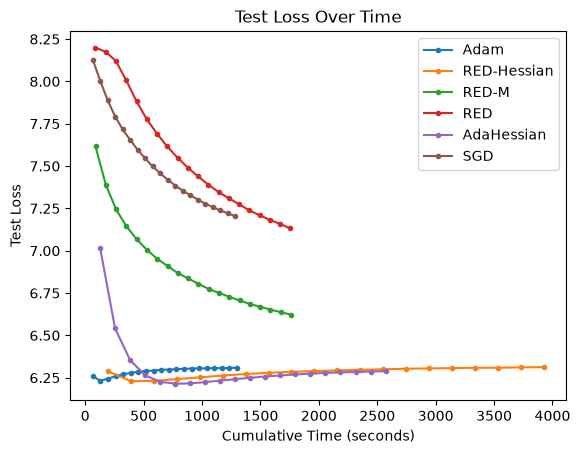

In [69]:
best_epch = {"adam":1,"redm":19,"sgd":19,"red":19,"adahessian":5,"redhessian":1}
print(best_epch["redm"])

def test_loss_over_time():
    with open("plot_data_2.pkl", "rb") as f:
        data = pickle.load(f)
    runtime = data['runtime']

    test_losses = data['loss_history_2']
    batch_size = 256

    for optim in optimizers:
        print(f"{optim}: {test_losses[optim][19]}")

    """

    for optim in optimizers:
        for N in networks[optim]:
            loss_layer = Neur.Ilogit_and_KL(None)
            N_a = Neur.Network([N, loss_layer])
            total_loss = 0
            batches = 0
        
            for k in range(0, len(X_test), batch_size):
                X_cur = get_cbow(X_test[k : k + batch_size])
                Y_cur = get_one_hot(Y_test[k : k + batch_size])

                loss_layer.save_D = Y_cur.T
                loss = N_a.forward(X_cur.T)

                total_loss += loss
                batches += 1

            test_losses[optim].append(total_loss / batches)

    """

    for optim, losses in test_losses.items():
        time_data = runtime[optim]
        times = [time_data[i] for i in range(len(losses))]
        plt.plot(times, losses, label=display[optim], marker="o", markersize=3)

    plt.xlabel("Cumulative Time (seconds)")
    plt.ylabel("Test Loss")
    plt.title("Test Loss Over Time")
    plt.legend()
    plt.show()

test_loss_over_time()
